In [26]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [27]:
df = pd.read_csv("../data/raw/smartcart_customers.csv")

In [28]:
## 1. Handle missing values

In [29]:
# df.shape
# df.isnull().sum()
df["Income"] = df["Income"].fillna(df["Income"].median())
# df.isnull().sum()

In [30]:
## 2. Handling dates

In [31]:
# Age

# df["Year_Birth"].max() -- 1996
df["Age"] = 1996 - df["Year_Birth"]

# Customer joining date

df["Dt_Customer"] =  pd.to_datetime(df["Dt_Customer"], dayfirst=True)

reference_date = df["Dt_Customer"].max()

df["Customer_Tenure_Days"] = (reference_date - df["Dt_Customer"]).dt.days

# df.head()
# df.columns

In [32]:
df.columns

Index(['ID', 'Year_Birth', 'Education', 'Marital_Status', 'Income', 'Kidhome',
       'Teenhome', 'Dt_Customer', 'Recency', 'MntWines', 'MntFruits',
       'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'Complain', 'Response', 'Age', 'Customer_Tenure_Days'],
      dtype='str')

In [33]:
## 3. Total spend and total childrens

In [34]:
# Total spending

df["Total_Spending"] = df["MntWines"] + df["MntFruits"] + df["MntMeatProducts"] + df["MntFishProducts"] + df["MntSweetProducts"] + df["MntGoldProds"]

# Total childrens

df["Total_Children"] = df["Kidhome"] + df["Teenhome"]
# df


In [35]:
## 4. Education & Martial status

In [36]:
# Education

# df["Education"].value_counts()

df["Education"] = df["Education"].replace({
    "Basic":"Undergraduate",
    "2n Cycle":"Undergraduate",
    "Graduation":"Graduate",
    "PhD":"Postgraduate",
    "Master":"Postgraduate",  
})

# df["Education"].value_counts()

#Martial status

#df["Marital_Status"].value_counts()

df["Living_With"] = df["Marital_Status"].replace({
    "Married":"Partner",
    "Together":"Partner",
    "Single":"Alone",
    "Divorced":"Alone",
    "Widow":"Alone",
    "Single":"Alone",
    "Absurd":"Alone",
    "YOLO":"Alone",  
})

#df["Living_With"].value_counts()
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Living_With
0,5524,1957,Graduate,Single,58138.0,0,0,2012-09-04,58,635,...,10,4,7,0,1,39,663,1617,0,Alone
1,2174,1954,Graduate,Single,46344.0,1,1,2014-03-08,38,11,...,1,2,5,0,0,42,113,27,2,Alone
2,4141,1965,Graduate,Together,71613.0,0,0,2013-08-21,26,426,...,2,10,4,0,0,31,312,776,0,Partner
3,6182,1984,Graduate,Together,26646.0,1,0,2014-02-10,26,11,...,0,4,6,0,0,12,139,53,1,Partner
4,5324,1981,Postgraduate,Married,58293.0,1,0,2014-01-19,94,173,...,3,6,5,0,0,15,161,422,1,Partner


In [37]:
## 5. Droping columns



In [38]:

cols = ["ID","Year_Birth","Marital_Status","Kidhome", "Teenhome", "Dt_Customer"]
spending_cols = ["MntWines","MntFruits","MntMeatProducts","MntFishProducts","MntSweetProducts","MntGoldProds"]

tot_cols = cols  + spending_cols

df_cleaned = df.drop(columns=tot_cols)

In [39]:
# df.shape
df_cleaned.shape

(2240, 15)

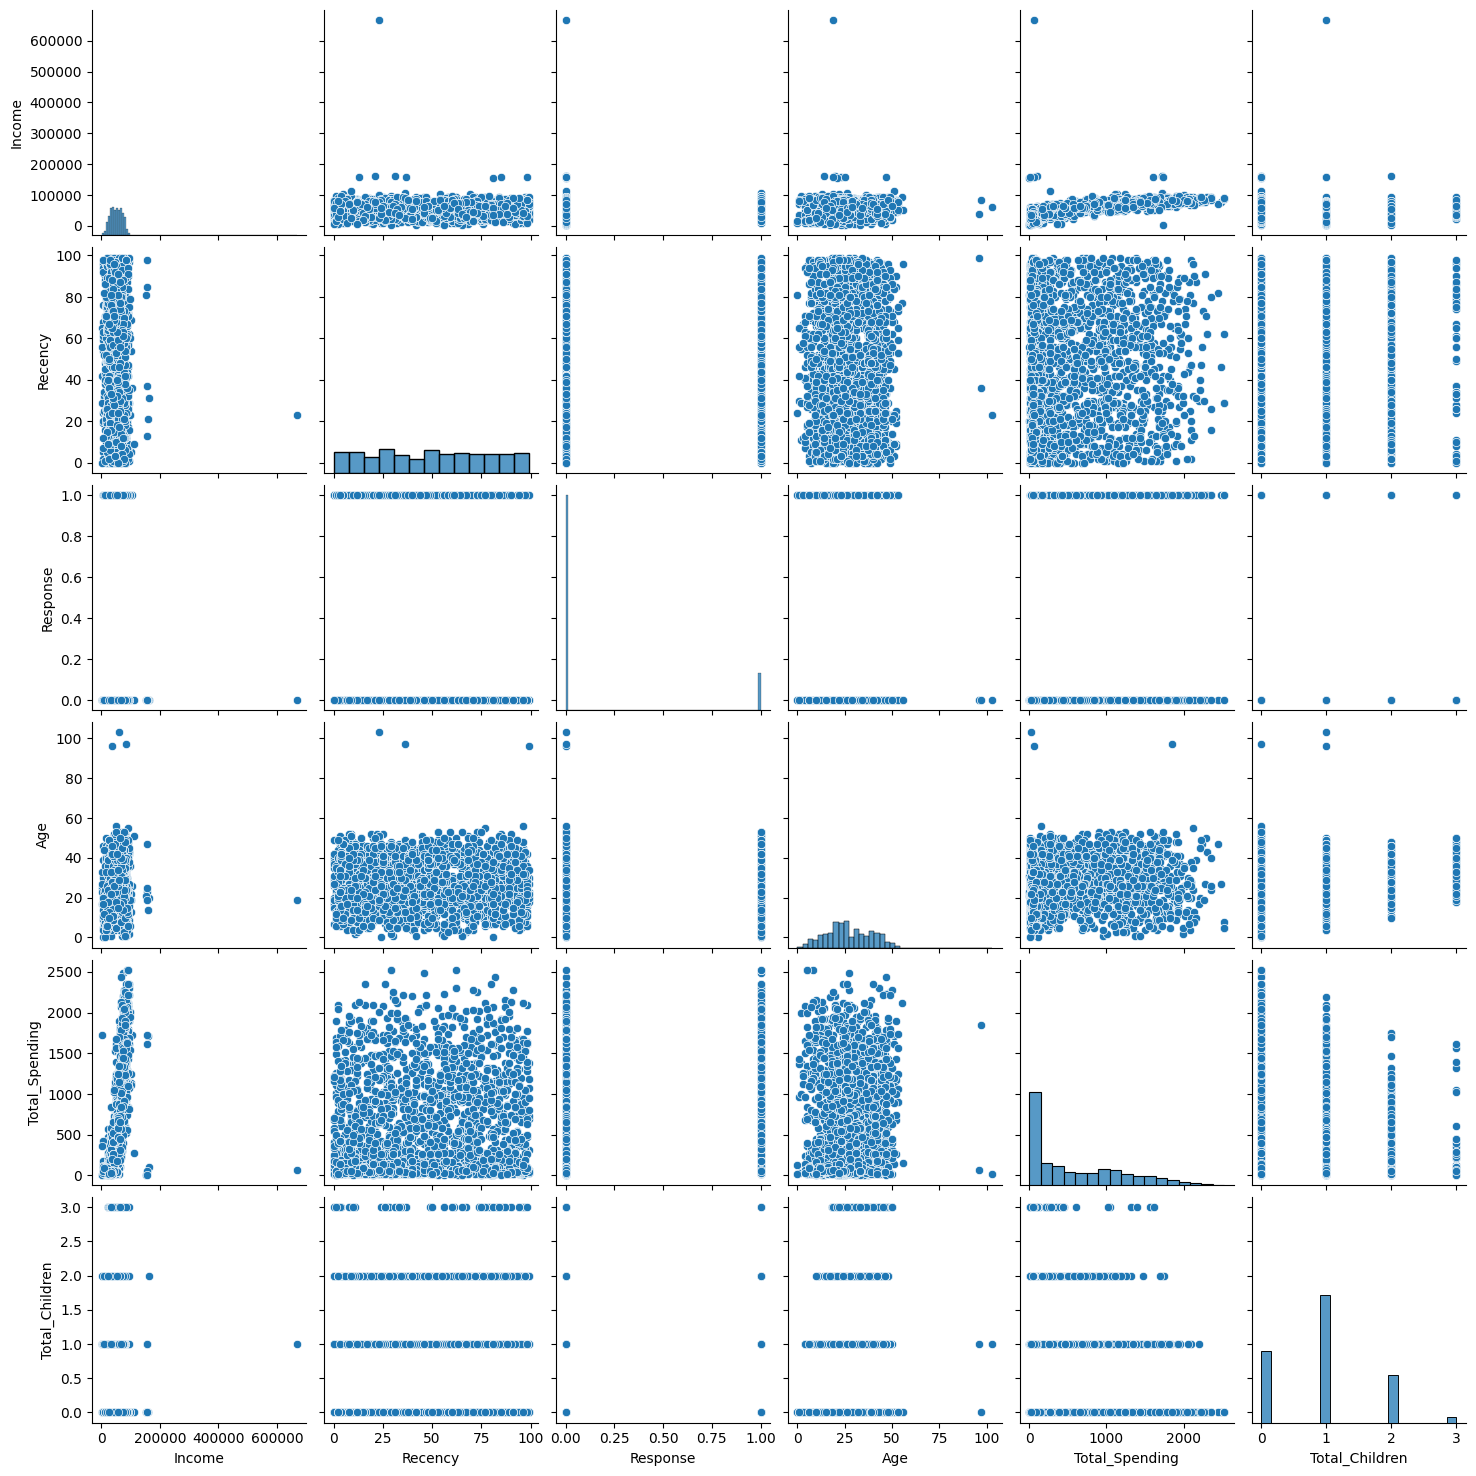

In [40]:
cols = ["Income","Recency","Response","Age","Total_Spending","Total_Children"]

sns.pairplot(df_cleaned[cols])

In [41]:
print("Size of dataset before outliers removal:", len(df_cleaned))

df_cleaned = df_cleaned[ (df_cleaned["Age"] < 90) ]
df_cleaned = df_cleaned[ (df_cleaned["Income"] < 600_000) ]

print("Size of dataset before outliers removal:", len(df_cleaned))

Size of dataset before outliers removal: 2240
Size of dataset before outliers removal: 2236


In [42]:
## Heatmap

<Axes: title={'center': 'Correaltion heatmap'}>

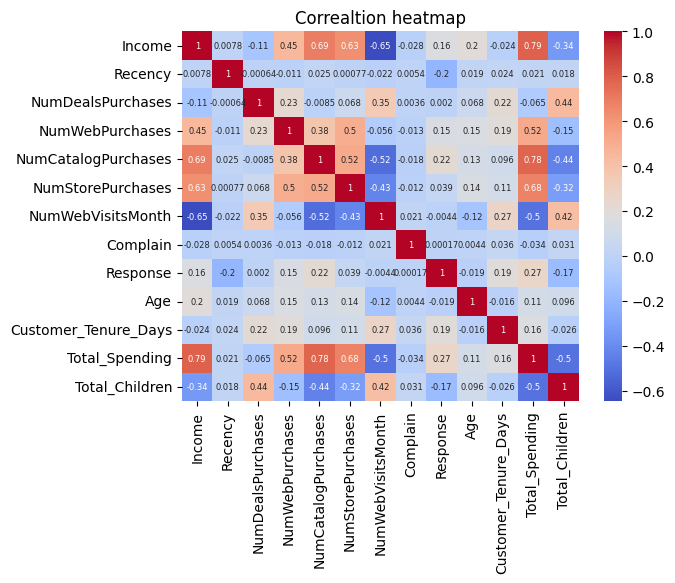

In [43]:
corr = df_cleaned.corr(numeric_only=True)

plt.title("Correaltion heatmap")
sns.heatmap(
    corr, 
    annot=True,
    annot_kws={"size":6},
    cmap="coolwarm"
)

# df_cleaned.shape

In [52]:
from sklearn.preprocessing import OneHotEncoder

ohe = OneHotEncoder()

cat_cols = ["Education","Living_With"]

encoded_cols = ohe.fit_transform(df_cleaned[cat_cols])

In [53]:
encoded_df = pd.DataFrame(encoded_cols.toarray(), columns=ohe.get_feature_names_out(cat_cols), index=df_cleaned.index)

In [54]:
df_encoded = pd.concat([df_cleaned.drop(columns=cat_cols),encoded_df ],axis=1)
df_encoded.shape

X = df_encoded

In [57]:
X

,Income,Recency,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,Complain,Response,Age,Customer_Tenure_Days,Total_Spending,Total_Children,Education_Graduate,Education_Postgraduate,Education_Undergraduate,Living_With_Alone,Living_With_Partner
0,58138.0,58,3,8,10,4,7,0,1,39,663,1617,0,1.0,0.0,0.0,1.0,0.0
1,46344.0,38,2,1,1,2,5,0,0,42,113,27,2,1.0,0.0,0.0,1.0,0.0
2,71613.0,26,1,8,2,10,4,0,0,31,312,776,0,1.0,0.0,0.0,0.0,1.0
3,26646.0,26,2,2,0,4,6,0,0,12,139,53,1,1.0,0.0,0.0,0.0,1.0
4,58293.0,94,5,5,3,6,5,0,0,15,161,422,1,0.0,1.0,0.0,0.0,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2235,61223.0,46,2,9,3,4,5,0,0,29,381,1341,1,1.0,0.0,0.0,0.0,1.0
2236,64014.0,56,7,8,2,5,7,0,0,50,19,444,3,0.0,1.0,0.0,0.0,1.0
2237,56981.0,91,1,2,3,13,6,0,0,15,155,1241,0,1.0,0.0,0.0,1.0,0.0
2238,69245.0,8,2,6,5,10,3,0,0,40,156,843,1,0.0,1.0,0.0,0.0,1.0


In [60]:
X.to_csv("../data/processed/processed_data.csv", index=False )


In [61]:
X.shape

(2236, 18)